week2 for all phases

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_loan = pd.read_csv("C:/Users/admin/Downloads/datasets/loan_portfolio_dataset.csv")

Matplotlib is building the font cache; this may take a moment.


In [2]:
df_loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   loan_id                800000 non-null  int64  
 1   customer_segment       800000 non-null  str    
 2   sanction_amount        800000 non-null  int64  
 3   outstanding_principal  800000 non-null  int64  
 4   interest_rate          800000 non-null  float64
 5   repricing_frequency    800000 non-null  str    
 6   prepayment_option      800000 non-null  str    
 7   collateral_type        800000 non-null  str    
 8   region                 800000 non-null  str    
 9   tenure_months          800000 non-null  int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 84.3 MB


In [2]:
df_loan.shape

(800000, 10)

In [3]:
df_loan.columns

Index(['loan_id', 'customer_segment', 'sanction_amount',
       'outstanding_principal', 'interest_rate', 'repricing_frequency',
       'prepayment_option', 'collateral_type', 'region', 'tenure_months'],
      dtype='str')

In [ ]:


segment_col = 'customer_segment'
region_col = 'region'
interest_col = 'interest_rate'
loan_amt_col = 'outstanding_principal'
tenure_col = 'tenure'
secured_col = 'secured_flag'

In [11]:
segment_exposure = df_loan.groupby('customer_segment')['outstanding_principal'].sum()


In [12]:
segment_exposure

customer_segment
Corporate    534904150243
Retail       534984745332
SME          533561561253
Name: outstanding_principal, dtype: int64

In [13]:
region_exposure = df_loan.groupby('region')['outstanding_principal'].sum()
region_exposure

region
Central    321821440369
East       321479379389
North      318214125087
South      320741981825
West       321193530158
Name: outstanding_principal, dtype: int64

In [15]:
df_loan['interest_rate'].describe()

count    800000.000000
mean         12.496878
std           3.175649
min           7.000000
25%           9.750000
50%          12.500000
75%          15.240000
max          18.000000
Name: interest_rate, dtype: float64

In [18]:
df_loan['tenure_months'].describe()

count    800000.000000
mean        125.485942
std          65.827576
min          12.000000
25%          68.000000
50%         126.000000
75%         182.000000
max         239.000000
Name: tenure_months, dtype: float64

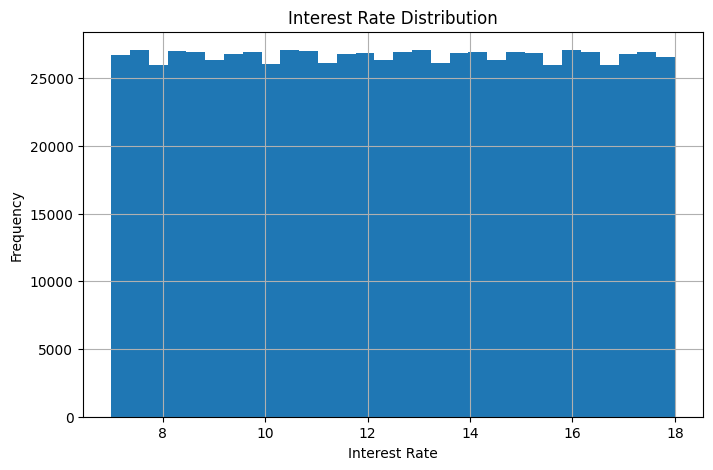

In [21]:
plt.figure(figsize=(8,5))
df_loan['interest_rate'].hist(bins=30)
plt.title("Interest Rate Distribution")
plt.xlabel("Interest Rate")
plt.ylabel("Frequency")
plt.show()

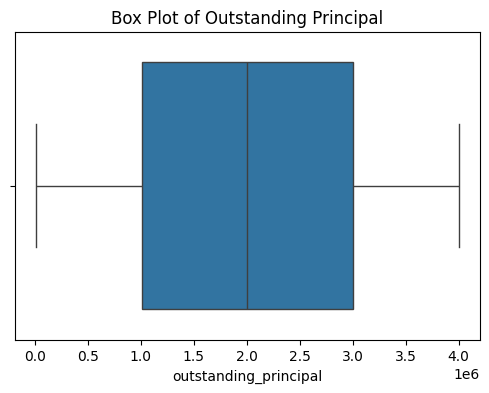

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_loan['outstanding_principal'])
plt.title("Box Plot of Outstanding Principal")
plt.show()

borrowing dataset for phase2

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_borr = pd.read_csv("C:/Users/admin/Downloads/datasets/borrowing_funding_dataset.csv")

df_borr.head()


,borrowing_id,funding_source,cost_of_funds,maturity_bucket,interest_reset_type,borrowing_amount,rollover_risk_score
0,1,NCD,9.07,6M,Floating,8928717,0.9472
1,2,Term Loan,8.69,6M,Floating,31344155,0.2102
2,3,Bank Line,7.46,6M,Floating,21925818,0.3430
3,4,NCD,8.45,3Y,Floating,11737224,0.9142
4,5,NCD,7.56,3Y,Fixed,43446206,0.6087


In [28]:
df_borr.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   borrowing_id         200000 non-null  int64  
 1   funding_source       200000 non-null  str    
 2   cost_of_funds        200000 non-null  float64
 3   maturity_bucket      200000 non-null  str    
 4   interest_reset_type  200000 non-null  str    
 5   borrowing_amount     200000 non-null  int64  
 6   rollover_risk_score  200000 non-null  float64
dtypes: float64(2), int64(2), str(3)
memory usage: 14.1 MB


In [ ]:
source_col = 'funding_source'     
amount_col = 'borrowing_amount'
cost_col = 'cost_of_funds'       
maturity_col = 'maturity_bucket'

In [31]:
funding_dist = df_borr.groupby('funding_source')['borrowing_amount'].sum()
funding_dist

funding_source
Bank Line           1280151079223
Commercial Paper    1272265925903
NCD                 1266729837342
Term Loan           1274613686226
Name: borrowing_amount, dtype: int64

In [34]:
df_borr['cost_of_funds'].describe()

count    200000.000000
mean          8.506839
std           2.021255
min           5.000000
25%           6.750000
50%           8.510000
75%          10.250000
max          12.000000
Name: cost_of_funds, dtype: float64

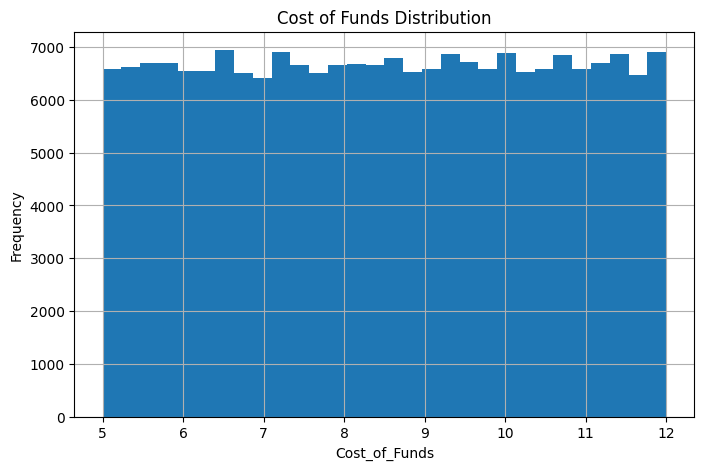

In [44]:
plt.figure(figsize=(8,5))
df_borr['cost_of_funds'].hist(bins=30)
plt.title("Cost of Funds Distribution")
plt.xlabel("Cost_of_Funds")
plt.ylabel("Frequency")
plt.show()

In [47]:
rollover_risk = df_borr[df_borr['maturity_bucket'].isin(['0-1M','1-6M'])] \
                .groupby('funding_source' )['cost_of_funds'].sum()

rollover_risk

Series([], Name: cost_of_funds, dtype: float64)

In [48]:
pivot = df_borr.pivot_table(values='borrowing_amount', 
                       index='funding_source'  , 
                       columns='maturity_bucket', 
                       aggfunc='sum')

pivot

maturity_bucket,1M,1Y,3M,3Y,6M
funding_source,,,,,
Bank Line,252155061182,259985637286,256808126811,257581150780,253621103164
Commercial Paper,256906388511,256629353935,253263150074,251150319750,254316713633
NCD,256609690696,248518245745,253509606379,251705390622,256386903900
Term Loan,253098710992,258433697693,254700757149,255971638094,252408882298


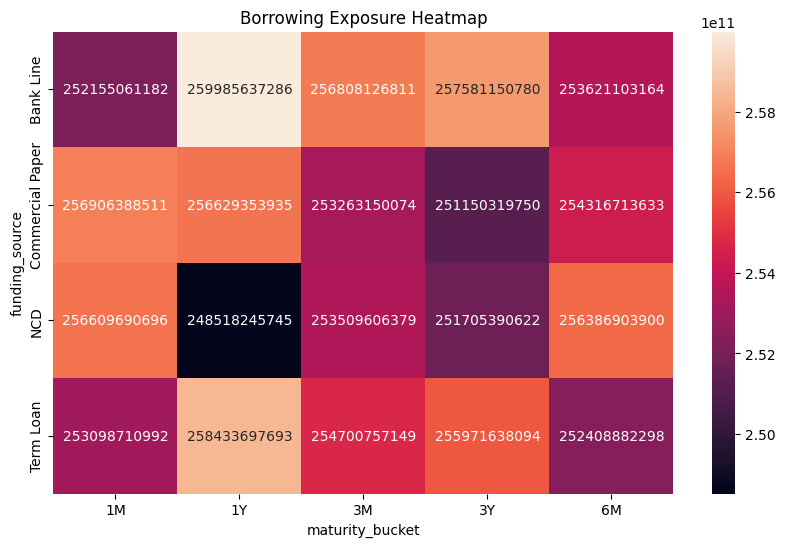

In [49]:
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Borrowing Exposure Heatmap")
plt.show()

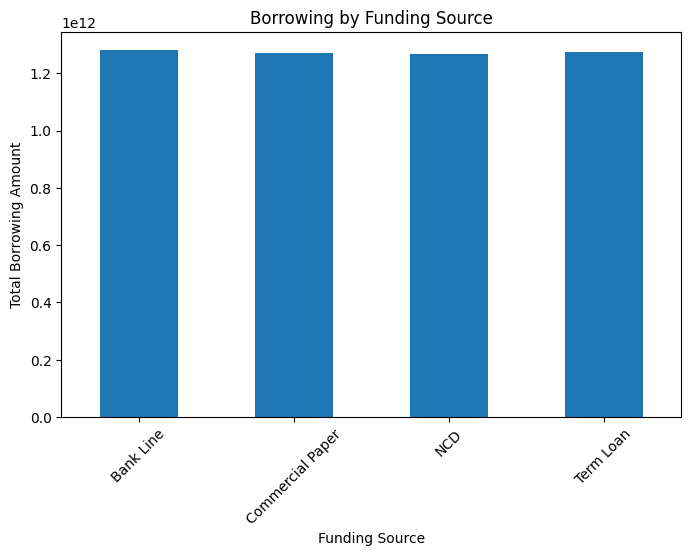

In [50]:
funding_source_dist = df_borr.groupby('funding_source')['borrowing_amount']

plt.figure(figsize=(8,5))
funding_dist.plot(kind='bar')
plt.title("Borrowing by Funding Source")
plt.xlabel("Funding Source")
plt.ylabel("Total Borrowing Amount")
plt.xticks(rotation=45)
plt.show()

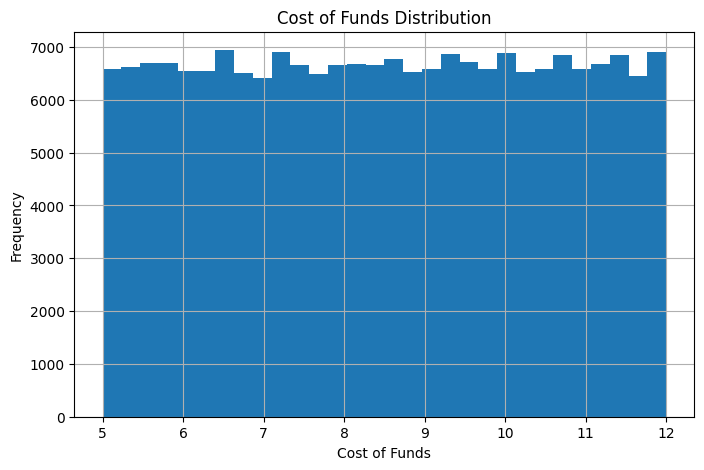

In [52]:
plt.figure(figsize=(8,5))
df_borr['cost_of_funds'].hist(bins=30)
plt.title("Cost of Funds Distribution")
plt.xlabel("Cost of Funds")
plt.ylabel("Frequency")
plt.show()

week 2 cash_flow_dataset

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_cash.head()
df_cash=pd.read_csv("C:/Users/admin/Downloads/datasets/daily_cashflow_dataset.csv")

In [55]:
df_cash.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   date             300000 non-null  str  
 1   inflow_type      300000 non-null  str  
 2   outflow_type     300000 non-null  str  
 3   expected_amount  300000 non-null  int64
 4   actual_amount    300000 non-null  int64
 5   variance         300000 non-null  int64
dtypes: int64(3), str(3)
memory usage: 23.4 MB


In [57]:
df_cash.dtypes

date                 str
inflow_type          str
outflow_type         str
expected_amount    int64
actual_amount      int64
variance           int64
dtype: object

In [58]:
df_cash.describe()

,expected_amount,actual_amount,variance
count,3.000000e+05,3.000000e+05,3.000000e+05
mean,2.502234e+06,2.508259e+06,6.024329e+03
std,1.439052e+06,1.439805e+06,2.035640e+06
min,1.000400e+04,1.000100e+04,-4.971602e+06
25%,1.253227e+06,1.262189e+06,-1.454054e+06
50%,2.502554e+06,2.514194e+06,5.525500e+03
75%,3.746451e+06,3.755466e+06,1.467227e+06
max,4.999994e+06,4.999944e+06,4.977697e+06


In [59]:
df_cash.shape

(300000, 6)

In [62]:
df_cash['date'] = pd.to_datetime(df_cash['date'])
df_cash = df_cash.sort_values('date')

In [63]:
df_cash

,date,inflow_type,outflow_type,expected_amount,actual_amount,variance
204195,2022-01-01,Fees,Principal Repayment,2314935,4535276,2220341
270483,2022-01-01,Prepayment,Principal Repayment,2596753,4046492,1449739
202953,2022-01-01,Fees,Principal Repayment,1827322,3325725,1498403
202689,2022-01-01,Fees,Interest Payment,4458225,458115,-4000110
245882,2022-01-01,Prepayment,Interest Payment,3427846,3257851,-169995
...,...,...,...,...,...,...
287550,2024-12-30,EMI,Principal Repayment,3586879,3567232,-19647
5317,2024-12-30,EMI,Principal Repayment,3344385,2492472,-851913
245295,2024-12-30,EMI,Operational Expense,4222368,55448,-4166920
216544,2024-12-30,Prepayment,Operational Expense,2207349,2487083,279734


In [67]:
df_cash[['date', 'expected_amount','actual_amount']].head()

,date,expected_amount,actual_amount
204195,2022-01-01,2314935,4535276
270483,2022-01-01,2596753,4046492
202953,2022-01-01,1827322,3325725
202689,2022-01-01,4458225,458115
245882,2022-01-01,3427846,3257851


In [70]:
df_cash['variance'] = df_cash['actual_amount'] - df_cash['expected_amount']
df_cash['net_liquidity'] = df_cash['actual_amount']  

In [71]:
df_cash['variance']

204195    2220341
270483    1449739
202953    1498403
202689   -4000110
245882    -169995
           ...   
287550     -19647
5317      -851913
245295   -4166920
216544     279734
163397   -3252442
Name: variance, Length: 300000, dtype: int64

In [72]:
df_cash['net_liquidity']

204195    4535276
270483    4046492
202953    3325725
202689     458115
245882    3257851
           ...   
287550    3567232
5317      2492472
245295      55448
216544    2487083
163397    1663619
Name: net_liquidity, Length: 300000, dtype: int64

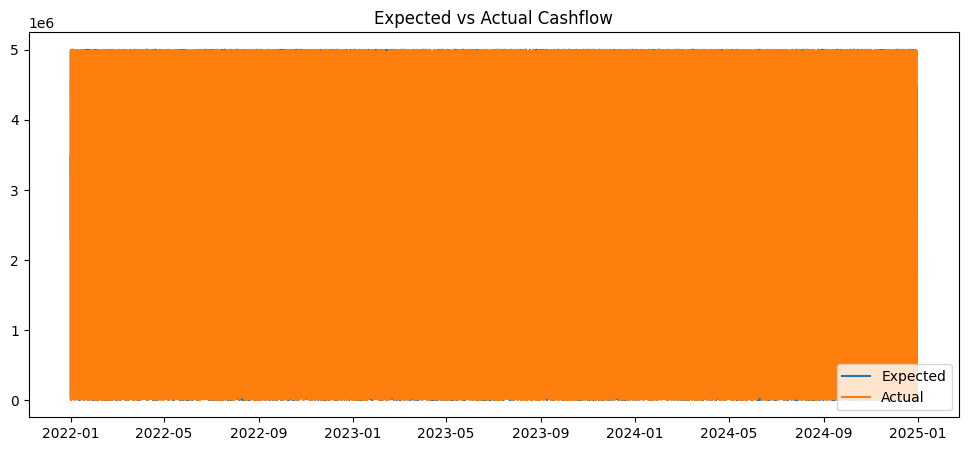

In [75]:
plt.figure(figsize=(12,5))
plt.plot(df_cash['date'], df_cash['expected_amount'], label='Expected')
plt.plot(df_cash['date'], df_cash['actual_amount'], label='Actual')
plt.legend()
plt.title("Expected vs Actual Cashflow")
plt.show()

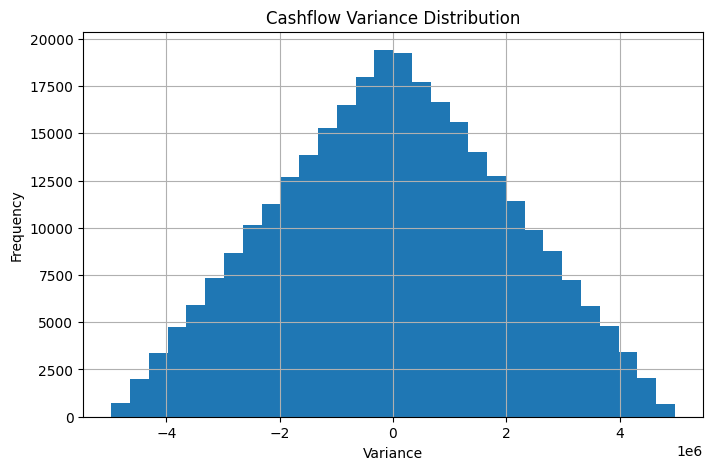

In [76]:
plt.figure(figsize=(8,5))
df_cash['variance'].hist(bins=30)
plt.title("Cashflow Variance Distribution")
plt.xlabel("Variance")
plt.ylabel("Frequency")
plt.show()

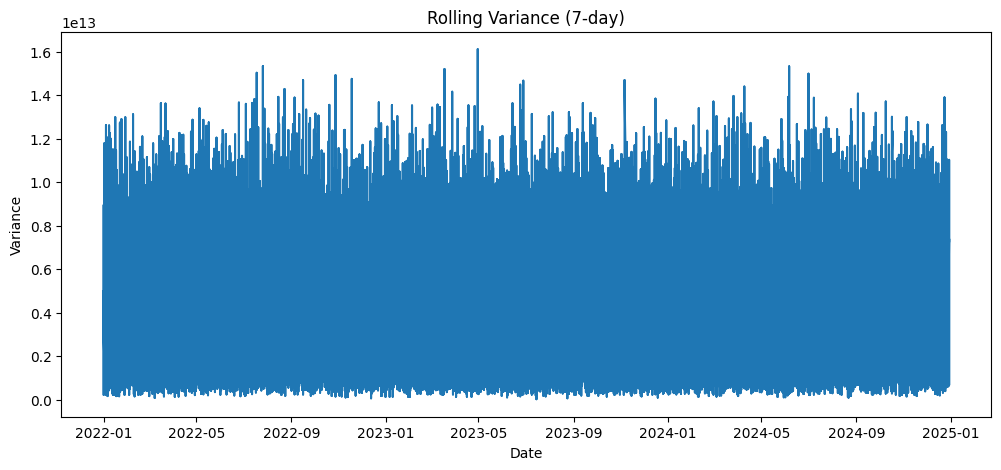

In [77]:
df_cash['rolling_variance'] = df_cash['variance'].rolling(window=7).var()

plt.figure(figsize=(12,5))
plt.plot(df_cash['date'], df_cash['rolling_variance'])
plt.title("Rolling Variance (7-day)")
plt.xlabel("Date")
plt.ylabel("Variance")
plt.show()

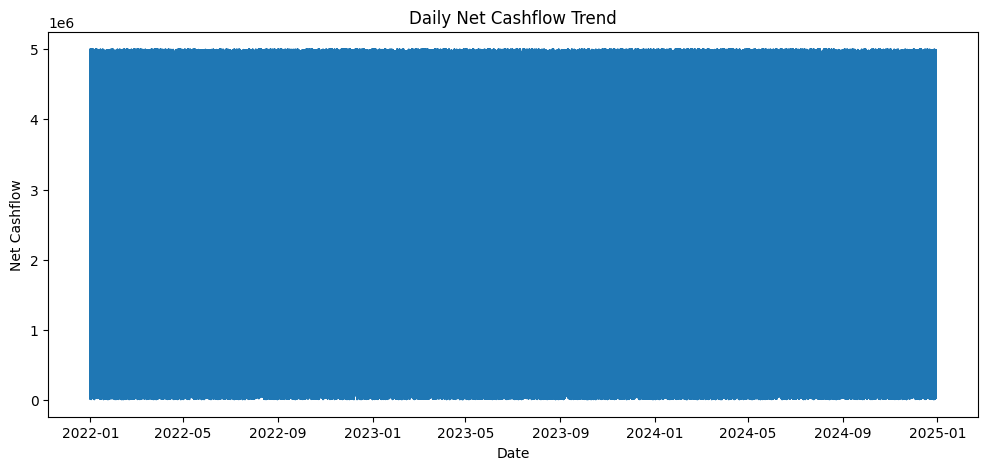

In [78]:
plt.figure(figsize=(12,5))
plt.plot(df_cash['date'], df_cash['net_liquidity'])
plt.title("Daily Net Cashflow Trend")
plt.xlabel("Date")
plt.ylabel("Net Cashflow")
plt.show()

In [79]:
df_cash['month'] = df_cash['date'].dt.to_period('M')

monthly_liquidity = df_cash.groupby('month')['net_liquidity'].sum()

monthly_liquidity

month
2022-01    21159021183
2022-02    19705940486
2022-03    21357987907
2022-04    20143910164
2022-05    21187304237
2022-06    20556294200
2022-07    21590388291
2022-08    21427511221
2022-09    20663658432
2022-10    21661856105
2022-11    20114132768
2022-12    21454015930
2023-01    21207094508
2023-02    19130158689
2023-03    21393799796
2023-04    20376078319
2023-05    21679630154
2023-06    21072661389
2023-07    21318311010
2023-08    20842736233
2023-09    20699110131
2023-10    21370932162
2023-11    20275691299
2023-12    21052512033
2024-01    21593578211
2024-02    19855208171
2024-03    21462369279
2024-04    20762446005
2024-05    21285299713
2024-06    20746200638
2024-07    21333598778
2024-08    21010654205
2024-09    20715005058
2024-10    20861302848
2024-11    20749890215
2024-12    20661312561
Freq: M, Name: net_liquidity, dtype: int64

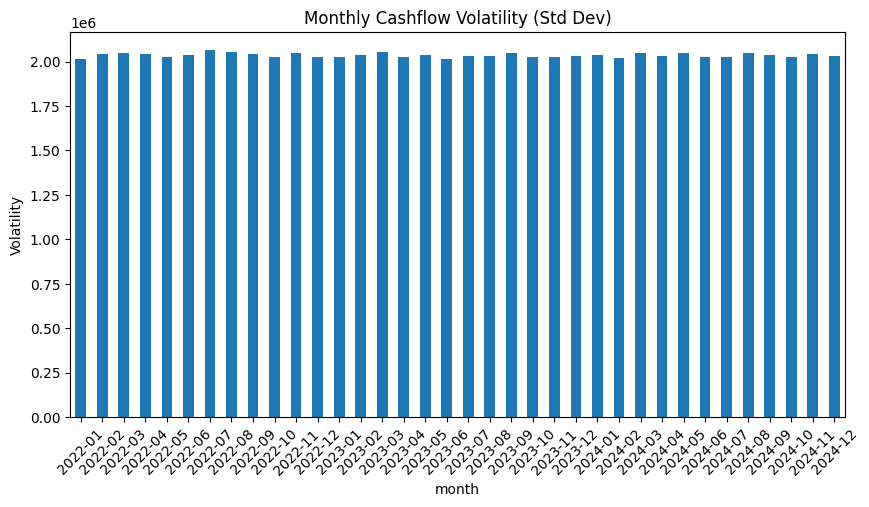

In [80]:
monthly_variance = df_cash.groupby('month')['variance'].std()

monthly_variance.plot(kind='bar', figsize=(10,5))
plt.title("Monthly Cashflow Volatility (Std Dev)")
plt.ylabel("Volatility")
plt.xticks(rotation=45)
plt.show()

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_macro = pd.read_csv("C:/Users/admin/Downloads/datasets/market_macro_dataset.csv")

df_macro.head()


,date,repo_rate,gsec_10y,cp_rate,inflation_cpi,liquidity_index,usd_inr
0,2023-05-04,6.32,8.28,5.41,7.30,-0.360,88.20
1,2024-09-16,5.16,5.66,6.93,7.04,-0.171,79.01
2,2024-08-14,4.53,7.01,7.27,4.50,0.991,80.84
3,2024-04-23,5.41,7.33,8.58,3.80,0.188,79.35
4,2024-02-10,4.87,7.35,8.71,5.42,1.748,89.54


In [83]:
df_macro.describe()

,repo_rate,gsec_10y,cp_rate,inflation_cpi,liquidity_index,usd_inr
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,5.749853,6.999804,7.000133,5.500726,0.000235,80.005830
std,1.009055,0.865009,1.154134,1.443123,1.156002,5.775332
min,4.000000,5.500000,5.000000,3.000000,-2.000000,70.000000
25%,4.880000,6.250000,6.000000,4.250000,-1.003000,75.000000
50%,5.750000,7.000000,7.000000,5.500000,0.002000,80.000000
75%,6.620000,7.750000,8.000000,6.750000,1.003000,85.010000
max,7.500000,8.500000,9.000000,8.000000,2.000000,90.000000


In [84]:
df_macro['date'] = pd.to_datetime(df_macro['date'])
df_macro = df_macro.sort_values('date')

In [85]:
df_macro

,date,repo_rate,gsec_10y,cp_rate,inflation_cpi,liquidity_index,usd_inr
204336,2022-01-01,4.93,6.91,7.70,5.60,-1.314,72.09
452217,2022-01-01,4.40,8.10,6.66,3.37,1.394,82.09
256819,2022-01-01,6.44,6.65,7.59,5.32,-1.341,82.67
163733,2022-01-01,5.13,5.66,8.38,6.39,0.908,77.32
452289,2022-01-01,4.39,8.15,8.29,4.84,0.238,75.73
...,...,...,...,...,...,...,...
591662,2024-12-30,5.89,6.05,5.33,7.89,-1.265,80.00
318839,2024-12-30,7.44,6.21,6.92,3.20,1.746,77.71
563398,2024-12-30,5.25,6.84,6.12,7.48,-0.758,79.81
329990,2024-12-30,5.51,7.97,5.84,4.81,-1.977,77.76


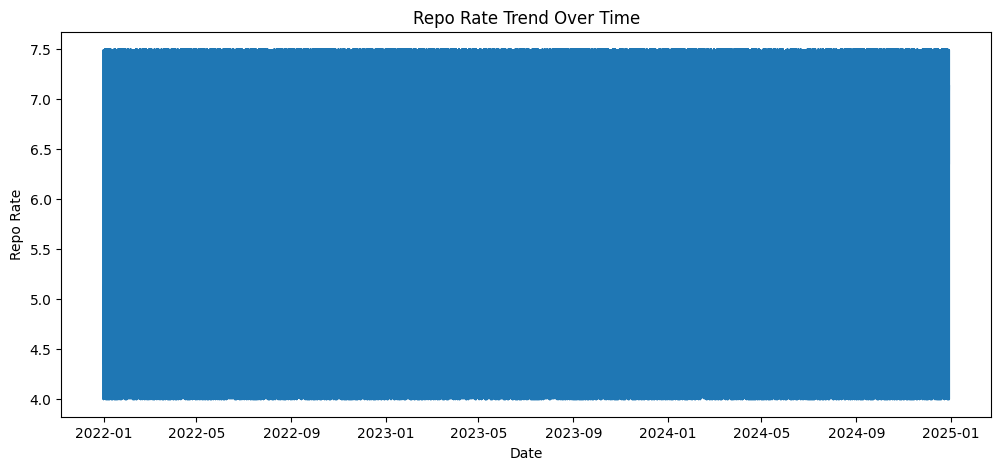

In [91]:
plt.figure(figsize=(12,5))
plt.plot(df_macro['date'], df_macro['repo_rate'])
plt.title("Repo Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Repo Rate")
plt.show()

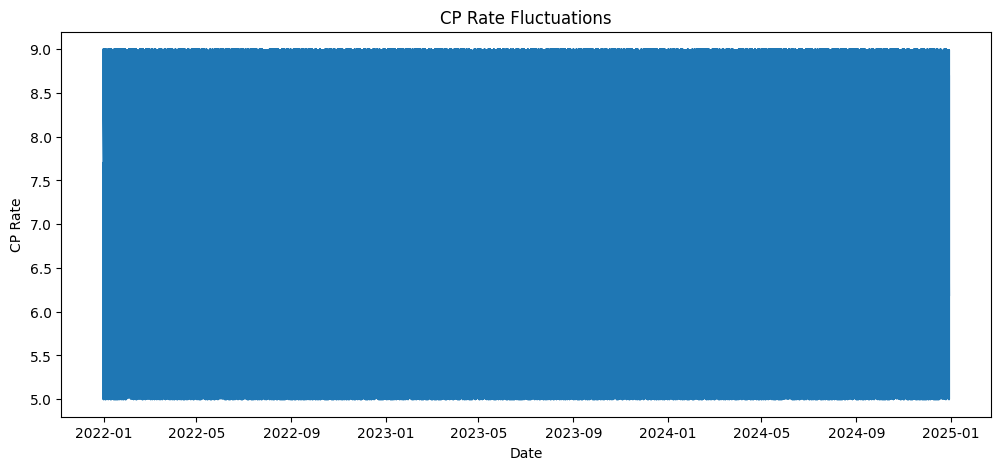

In [92]:
plt.figure(figsize=(12,5))
plt.plot(df_macro['date'], df_macro['cp_rate'])
plt.title("CP Rate Fluctuations")
plt.xlabel("Date")
plt.ylabel("CP Rate")
plt.show()

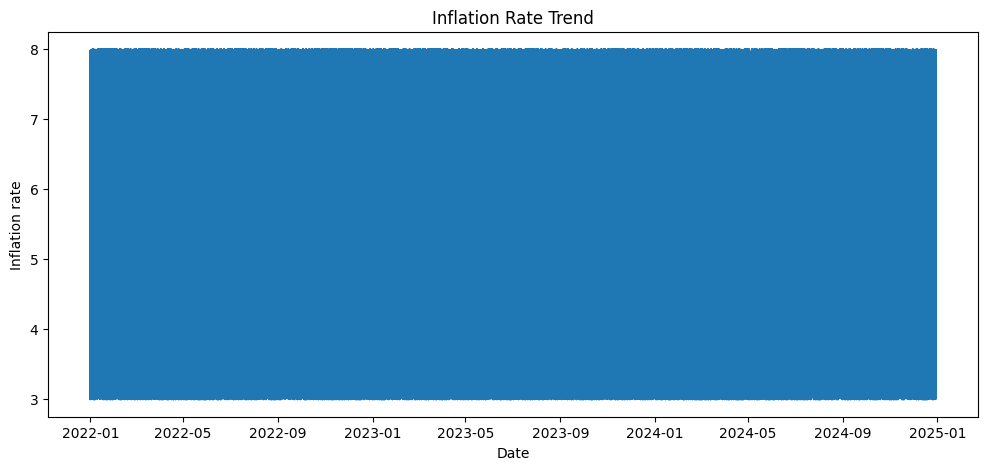

In [95]:
plt.figure(figsize=(12,5))
plt.plot(df_macro['date'],df_macro['inflation_cpi'])
plt.title("Inflation Rate Trend")
plt.xlabel("Date")
plt.ylabel("Inflation rate")
plt.show()

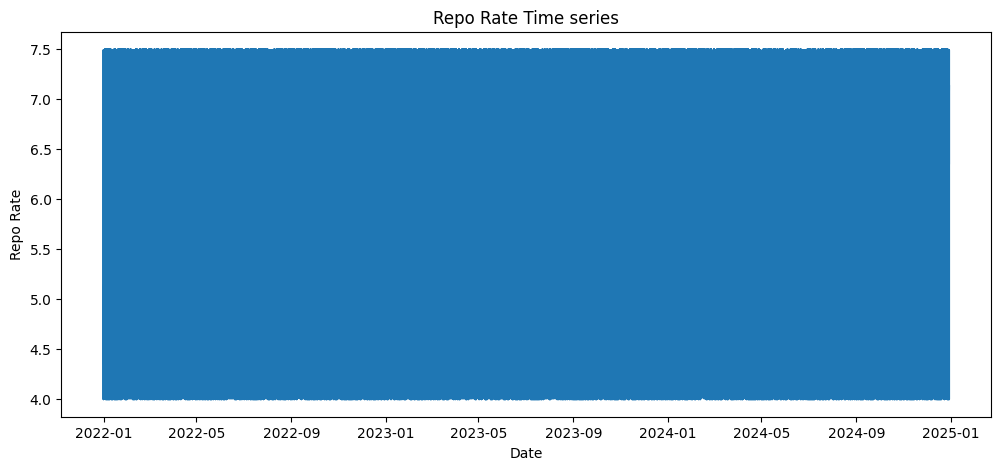

In [96]:
plt.figure(figsize=(12,5))
plt.plot(df_macro['date'], df_macro['repo_rate'])
plt.title("Repo Rate Time series")
plt.xlabel("Date")
plt.ylabel("Repo Rate")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_24368\3222200197.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


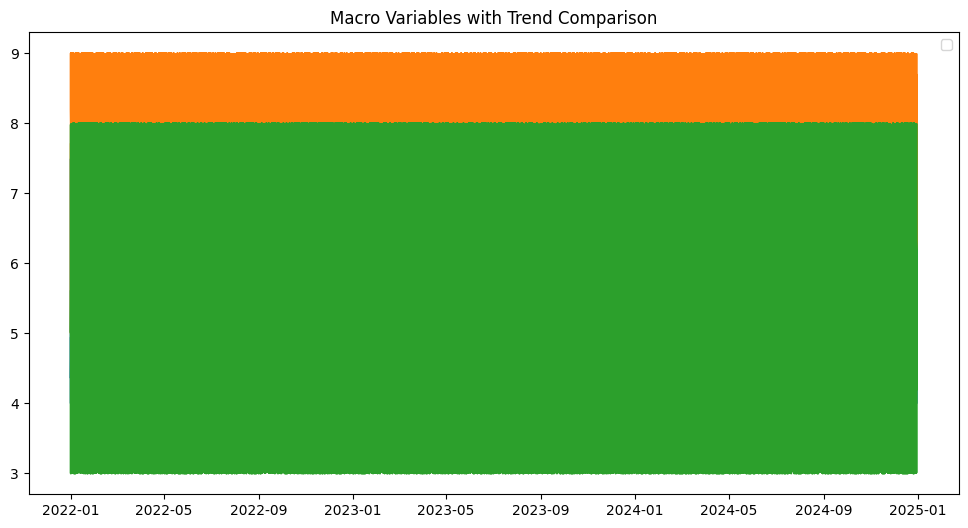

In [101]:
plt.figure(figsize=(12,6))

plt.plot(df_macro['date'], df_macro['repo_rate'])
plt.plot(df_macro['date'], df_macro['cp_rate'])
plt.plot(df_macro['date'], df_macro['inflation_cpi'])

plt.legend()
plt.title("Macro Variables with Trend Comparison")
plt.show()